In [ ]:
import torch
import numpy as np
import pandas as pd
import random
import os
from collections import Counter
from sklearn import tree as sktree
from sklearn.cluster import DBSCAN
from lark import Tree, Token

from config import DATA_DIR
from core import *
from utils import *
import matplotlib.pyplot as plt

NARY = 1
PROBABILITIES = 0.2,0.2,0.2,0.4
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

In [2]:
iterations = 15  # Quante iterazioni diverse (numero regioni prima di minimizzare in teoria)
current_string = SEED_STRING
for _ in range(iterations):
    current_string = replace_random_underscore(current_string, PROBABILITIES)

process = replace_underscores(current_string)
tree = PARSER.parse(process)

# Albero con 2 LOOP (stesso usato in main.ipynb)
tree = Tree('xor', [
    Tree('sequential', [
        Tree('loop', [
            Tree('task', [Token('NAME', 'T1')])
        ]),
        Tree('xor', [
            Tree('task', [Token('NAME', 'T2')]),
            Tree('task', [Token('NAME', 'T3')])
        ])
    ]),
    Tree('parallel', [
        Tree('loop', [   # loop inserito in un ramo del parallel
            Tree('task', [Token('NAME', 'T4')])
        ]),
        Tree('task', [Token('NAME', 'T5')])
    ])
])

if NARY:
    tree = createNAryTree(tree)

print(tree)

Tree('xor', [Tree('sequential', [Tree('loop', [Tree('task', [Token('NAME', 'T1')])]), Tree('xor', [Tree('task', [Token('NAME', 'T2')]), Tree('task', [Token('NAME', 'T3')])])]), Tree('parallel', [Tree('loop', [Tree('task', [Token('NAME', 'T4')])]), Tree('task', [Token('NAME', 'T5')])])])


In [3]:
# Oggetto PetriNetP e Generator

net = PetriNetP(tree)
generator = Generator(30000, net)
generator.generateTrace(False)

[['start_X0',
  'start_P4',
  'start_L5',
  'start_T4',
  'end_T4',
  'end_L5',
  'start_T5',
  'end_T5',
  'end_P4',
  'end_X0'],
 ['start_X0',
  'start_P4',
  'start_L5',
  'start_T5',
  'start_T4',
  'end_T5',
  'end_T4',
  'end_L5',
  'end_P4',
  'end_X0'],
 ['start_X0',
  'start_L2',
  'start_T1',
  'end_T1',
  'end_L2',
  'start_X3',
  'start_T2',
  'end_T2',
  'end_X3',
  'end_X0'],
 ['start_X0',
  'start_L2',
  'start_T1',
  'end_T1',
  'back_L2',
  'start_T1',
  'end_T1',
  'end_L2',
  'start_X3',
  'start_T3',
  'end_T3',
  'end_X3',
  'end_X0'],
 ['start_X0',
  'start_P4',
  'start_L5',
  'start_T4',
  'start_T5',
  'end_T4',
  'end_L5',
  'end_T5',
  'end_P4',
  'end_X0'],
 ['start_X0',
  'start_P4',
  'start_L5',
  'start_T5',
  'end_T5',
  'start_T4',
  'end_T4',
  'back_L5',
  'start_T4',
  'end_T4',
  'back_L5',
  'start_T4',
  'end_T4',
  'end_L5',
  'end_P4',
  'end_X0'],
 ['start_X0',
  'start_L2',
  'start_T1',
  'end_T1',
  'end_L2',
  'start_X3',
  'start_T3',
  '

In [4]:
# Creazione dei decision tree per 'limitare' i loop e provare a dargli un 'senso'
classifier_dict_loop = {}

for loop in net.loop_regions:
    result = create_loop_data(loop, generator.generatedTraces)
    if result is None:
        continue

    x, y, dict_loop_step_encoding, max_len = result

    dt = sktree.DecisionTreeClassifier(max_depth=5, class_weight='balanced') #Se mettiamo class_weight='balanced' è come se avessimo pompato le tracce
    dt.fit(x, y)
    classifier_dict_loop[loop] = (dt, dict_loop_step_encoding, max_len)

print(classifier_dict_loop)

{'L2': (DecisionTreeClassifier(class_weight='balanced', max_depth=5), {'start_X0': 0, 'end_T1': 1, 'start_T1': 2, 'start_L2': 3, 'back_L2': 4, 'PAD': 5}, 46), 'L5': (DecisionTreeClassifier(class_weight='balanced', max_depth=5), {'start_L5': 0, 'end_T5': 1, 'start_X0': 2, 'end_T4': 3, 'start_P4': 4, 'back_L5': 5, 'PAD': 6, 'start_T4': 7, 'start_T5': 8}, 49)}


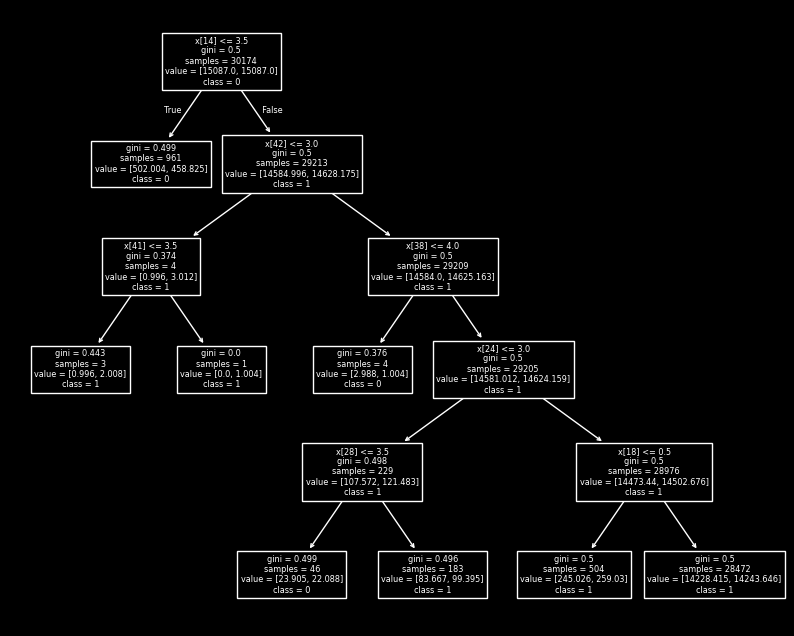

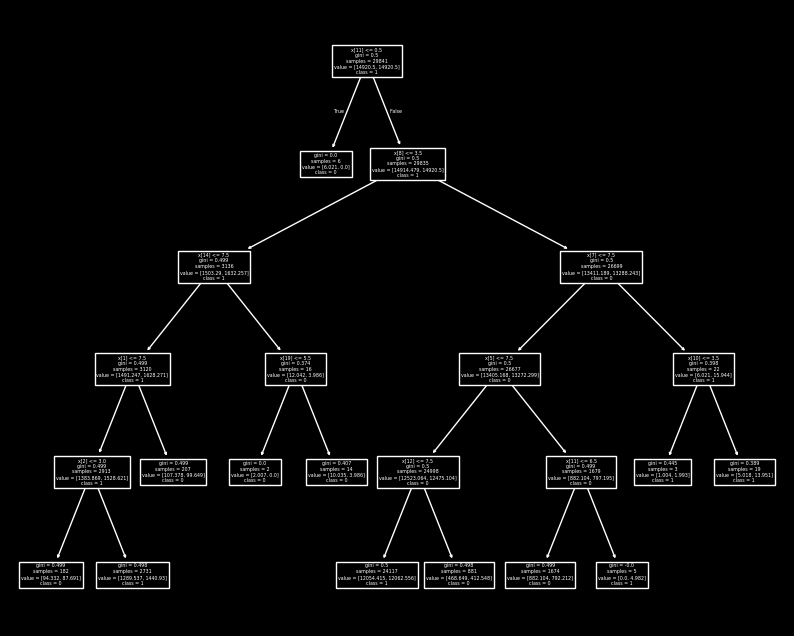

In [5]:
for clf,_,_ in classifier_dict_loop.values():
    plt.figure(figsize=(10, 8))
    sktree.plot_tree(clf,
               class_names=["0", "1"])
    plt.show()

In [6]:
# Rigenero le tracce utilizzando i classificatori
generator.generateTraceCond(classifier_dict_loop)

[['start_T5', 'end_T5', 'start_T4', 'end_T4', 'end_L5'],
 ['start_T5', 'end_T5', 'start_T4', 'end_T4', 'end_L5'],
 ['start_T5', 'end_T5', 'start_T4', 'end_T4', 'end_L5'],
 ['start_T4', 'start_T5', 'end_T4', 'end_L5', 'end_T5'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T2', 'end_T2'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T3', 'end_T3'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T2', 'end_T2'],
 ['start_T5', 'start_T4', 'end_T5', 'end_T4', 'end_L5'],
 ['start_T4', 'start_T5', 'end_T5', 'end_T4', 'end_L5'],
 ['start_T4', 'start_T5', 'end_T4', 'end_L5', 'end_T5'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T2', 'end_T2'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T3', 'end_T3'],
 ['start_T4', 'end_T4', 'end_L5', 'start_T5', 'end_T5'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T2', 'end_T2'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T2', 'end_T2'],
 ['start_T5', 'end_T5', 'start_T4', 'end_T4', 'end_L5'],
 ['start_T4', 'end_T4', 'end_L5', 'start_T5', 'end_T5'],
 ['start_T4', 'start_T5', 'end_

In [7]:
# Creazione matrice identità delle regioni
df_region_identity = pd.DataFrame.from_dict(net.node_identity, orient='index').sort_index()
df_region_identity.columns = ['X', '+', '->', '<>']
print(df_region_identity)

# Creazione matrice regioni-figli per le regioni
df_region_children = pd.Series(net.node_children).explode()
df_region_children = pd.crosstab(df_region_children.index, df_region_children)
df_region_children = df_region_children.reindex(index=net.regions, columns=net.regions + net.tasks, fill_value=0)
df_region_children = df_region_children.astype(int)
df_region_children.index.name = None
df_region_children.columns.name = None
print(df_region_children)

# Codifica delle tracce generate
traceEncoded_regions, traceEncoded_tasks = get_encoding(
    generator.generatedTraces, net.regions, net.tasks, net.open_clauses, net.end_clauses
)

# Trovo numero regioni e numero task effettivo
num_regions = len([i for i in traceEncoded_regions.index if str(i).startswith('R')])
num_tasks = len([i for i in traceEncoded_tasks.index   if str(i).startswith('T')])

# Creo il dataframe unico (regioni + task)
df_traces_complete = pd.concat([traceEncoded_regions, traceEncoded_tasks], axis=0)
print(f'num_regions={num_regions}, num_tasks={num_tasks}, shape={df_traces_complete.shape}')

    X  +  ->  <>
R0  1  0   0   0
R1  0  0   1   0
R2  0  0   0   1
R3  1  0   0   0
R4  0  1   0   0
R5  0  0   0   1
    R0  R1  R2  R3  R4  R5  T1  T2  T3  T4  T5
R0   0   1   0   0   1   0   0   0   0   0   0
R1   0   0   1   1   0   0   0   0   0   0   0
R2   0   0   0   0   0   0   1   0   0   0   0
R3   0   0   0   0   0   0   0   1   1   0   0
R4   0   0   0   0   0   1   0   0   0   0   1
R5   0   0   0   0   0   0   0   0   0   1   0
num_regions=6, num_tasks=5, shape=(11, 120000)


In [8]:
'''Prendo tutte le tracce, le conto e poi creo una matrice di distanza tra tutte le possibili tracce --> mi servirà per la creazione dei cluster'''

all_traces = getall_traces(num_regions + num_tasks, df_traces_complete) # Ritorno la lista di tutte le tracce
trace_counts = Counter(all_traces) # Conto quante occorrenze ci sono per traccia
traces_encoded = list(trace_counts.keys()) # Prendo le tracce
trace_weights = list(trace_counts.values()) # I pesi solo le occorrenze
n_traces = len(traces_encoded) # Numero tracce diverse fra loro

distance_matrix = create_distance_matrix(n_traces, traces_encoded, num_regions + num_tasks) # Creo la matrice di distanza utilizzando la weighted levenshtein (con hamming_distance)
print(f'Distance matrix: {distance_matrix.shape}')

Distance matrix: (8, 8)


In [9]:
# Clusterizzo
dbscan = DBSCAN(eps=25, min_samples=1, metric='precomputed')
dbscan.fit(distance_matrix, sample_weight=trace_weights)
cluster_labels = dbscan.labels_
print(f'Clusters trovati: {len(set(cluster_labels))}')

df_clusters = pd.DataFrame({
    'Trace_Type': [str(t) for t in traces_encoded],
    'Frequency': trace_weights,
    'N_Cluster': cluster_labels
})
df_clusters = df_clusters.sort_values(by=['N_Cluster', 'Frequency'], ascending=[True, False])

df_clusters

Clusters trovati: 1


,Trace_Type,Frequency,N_Cluster
2,"((1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0), (1, 1, 0, ...",7584,0
3,"((1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0), (1, 1, 0, ...",7375,0
0,"((1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1), (1, 0, 0, ...",3724,0
6,"((1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0), (1, 0, 0, ...",3694,0
4,"((1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1), (1, 0, 0, ...",1955,0
5,"((1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0), (1, 0, 0, ...",1927,0
1,"((1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0), (1, 0, 0, ...",1876,0
7,"((1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1), (1, 0, 0, ...",1865,0


In [10]:
'''Prendo tot tracce per cluster --> per bilanciare le tracce generate e per non avere prevalentemente tracce dello stesso cluster'''

num_trace_per_cluster = 1000
balanced_traces, balanced_columns = get_balance_traces_by_cluster(
    traces_encoded, cluster_labels, num_trace_per_cluster
)

df_traces_balanced = pd.DataFrame(balanced_columns).T
df_traces_balanced.index = df_traces_complete.index
print(df_traces_balanced)

    0     1     2     3     4     5     6     7     8     9     ...  3990  \
R0     1     1     1     0     1     1     1     0     1     1  ...     1   
R1     0     0     0     0     1     1     1     0     0     0  ...     0   
R2     0     0     0     0     1     0     0     0     0     0  ...     0   
R3     0     0     0     0     0     0     1     0     0     0  ...     0   
R4     1     1     1     0     0     0     0     0     1     1  ...     1   
R5     1     1     1     0     0     0     0     0     1     1  ...     1   
T1     0     0     0     0     1     0     0     0     0     0  ...     0   
T2     0     0     0     0     0     0     0     0     0     0  ...     0   
T3     0     0     0     0     0     0     1     0     0     0  ...     0   
T4     1     1     1     0     0     0     0     0     1     1  ...     1   
T5     0     1     0     0     0     0     0     0     0     1  ...     0   

    3991  3992  3993  3994  3995  3996  3997  3998  3999  
R0     0     1  

In [11]:
# Prendo i rispettivi dataframe per le regioni e per le task
df_regions = df_traces_balanced.head(num_regions).copy()
df_tasks   = df_traces_balanced.tail(num_tasks).copy()

df_traces_balanced_T = df_traces_balanced.T.copy()

# Vocabolario completo (regioni + task)
unique_cols_complete = df_traces_balanced_T.drop_duplicates()
unique_tup_complete  = [tuple(x) for x in unique_cols_complete.values]
bit_to_id_complete   = {v: i for i, v in enumerate(unique_tup_complete)}
id_to_bit_complete   = {i: v for i, v in enumerate(unique_tup_complete)}
vocab_size_complete  = len(unique_cols_complete)
encode_complete      = lambda a: [bit_to_id_complete[tuple(x)] for x in a]
decode_complete      = lambda b: [id_to_bit_complete[x] for x in b]

# Vocabolario regioni
df_regions_T        = df_regions.T
unique_cols_regions = df_regions_T.drop_duplicates()
unique_tup_regions  = [tuple(x) for x in unique_cols_regions.values]
bit_to_id_regions   = {v: i for i, v in enumerate(unique_tup_regions)}
id_to_bit_regions   = {i: v for i, v in enumerate(unique_tup_regions)}
vocab_size_regions  = len(unique_cols_regions)
encode_regions      = lambda a: [bit_to_id_regions[tuple(x)] for x in a]
decode_regions      = lambda b: [id_to_bit_regions[x] for x in b]

# Vocabolario task
df_tasks_T        = df_tasks.T
unique_cols_tasks = df_tasks_T.drop_duplicates()
unique_tup_tasks  = [tuple(x) for x in unique_cols_tasks.values]
bit_to_id_tasks   = {v: i for i, v in enumerate(unique_tup_tasks)}
id_to_bit_tasks   = {i: v for i, v in enumerate(unique_tup_tasks)}
vocab_size_tasks  = len(unique_cols_tasks)
encode_tasks      = lambda a: [bit_to_id_tasks[tuple(x)] for x in a]
decode_tasks      = lambda b: [id_to_bit_tasks[x] for x in b]

print(f'vocab complete={vocab_size_complete}, regions={vocab_size_regions}, tasks={vocab_size_tasks}')

vocab complete=9, regions=6, tasks=7


In [12]:
# Decodifico le tracce bilanciate con la funzione get_decoding
traces_balanced_decoded = get_decoding(balanced_traces, net.regions, net.tasks)

possible_tasks = [] # Per ogni task dobbiamo considerare sia start_'task' sia end_'task' --> per la generazione dei tempi
for task in net.tasks:
    possible_tasks.append(f'start_{task}')
    possible_tasks.append(f'end_{task}')

k_partition = 3
max_depth = 5

# Seleziono k-pattern per differenziare i tempi delta dei vari step (ex: in modo che start_T1 non abbia sempre 4)
tree_times_task_dict = {}
for task in possible_tasks:
    miner = TracePatternMiner()
    miner.root.name = task # Sovrascrivo il nome della radice (sarà la parte di task che sto usando)

    num_traces_for_task = 0
    for trace in traces_balanced_decoded:
        if task in trace: # Se la task è presente nella traccia
            idx = trace.index(task) # Prendo l'indice della task
            subtrace_task = trace[:idx] # Prendo la traccia fino al punto del task (task escluso)
            reversed_subtrace = list(reversed(subtrace_task)) # Giro la traccia presa --> la considero al contrario
            miner.fit_trace(reversed_subtrace, max_depth) # Vado a conteggiarla nel miner
            num_traces_for_task += 1

    # or len(miner.nodes) == 0
    if num_traces_for_task == 0 or len(miner.nodes) == 0: # Se non ho trovato nemmeno una partecipazione di quella task (in teoria NON dovrebbe capitare)
        tree_times_task_dict[task] = {
            'partitions': {'RESIDUALS': {'numTraces': num_traces_for_task, 'nodes': []}},
            'times_map':  {'RESIDUALS': 0.0} # Se non ha storia, il tempo normalizzato è sempre il minimo (0.0)
        }
        continue

    partitions = miner.select_patterns(num_traces_for_task, k_partition) # Cerco i pattern
    times_map = miner.create_normalized_time_map(partitions) # Creo il mapping time partitions --> assegno un delta ad ogni partizione (con funzione esponenziale)
    tree_times_task_dict[task] = {'partitions': partitions, 'times_map': times_map}
    print(task)
    print(times_map)

{'RESIDUALS': {'numTraces': 273, 'nodes': [<core.models.PatternTree.NodoPattern object at 0x0000025E2FAD4320>]}}
Partizione: -start_T1 | Tracce coperte: 273
end_T1
{'-start_T1': 1.0}
{'RESIDUALS': {'numTraces': 141, 'nodes': [<core.models.PatternTree.NodoPattern object at 0x0000025E280347D0>, <core.models.PatternTree.NodoPattern object at 0x0000025E28037110>]}}
Partizione: -end_T1-start_T1 | Tracce coperte: 141
start_T2
{'-end_T1-start_T1': 1.0}
{'RESIDUALS': {'numTraces': 141, 'nodes': [<core.models.PatternTree.NodoPattern object at 0x0000025E2FAD42C0>, <core.models.PatternTree.NodoPattern object at 0x0000025E2FAD42F0>, <core.models.PatternTree.NodoPattern object at 0x0000025E2FAD4380>]}}
Partizione: -start_T2-end_T1-start_T1 | Tracce coperte: 141
end_T2
{'-start_T2-end_T1-start_T1': 1.0}
{'RESIDUALS': {'numTraces': 132, 'nodes': [<core.models.PatternTree.NodoPattern object at 0x0000025E2FAD4440>, <core.models.PatternTree.NodoPattern object at 0x0000025E2FAD4470>]}}
Partizione: -end_T

In [13]:
# A questo punto assegno i tempi alle tracce (basandomi sui pattern che ho già trovato in precedenza)
times = []
trace_times_list = []
window = 5

for trace in traces_balanced_decoded: # Assegno i tempi alle tracce
    this_trace_times = []
    for i, element in enumerate(trace):
        if i == 0:
            this_trace_times.append(0.0)
            times.append(0.0)
            continue
        times_map = tree_times_task_dict[element]['times_map']
        generated_time = assign_time(trace[:i], times_map, window)
        this_trace_times.append(generated_time)
        times.append(generated_time)

    print(this_trace_times)
    trace_times_list.append(this_trace_times)

print(f'Time steps totali: {len(times)}')

[0.0, 0.4286, 1.0, 1.0]
[0.0, 1.0, 1.0, 1.0]
[0.0, 0.4286, 0.1429, 0.1429]
[0.0, 1.0, 1.0, 1.0]
[0.0, 0.4286, 0.1429, 0.1429]
[0.0, 0.4286, 1.0, 0.4286]
[0.0, 1.0, 1.0, 1.0]
[0.0, 0.4286, 0.1429, 0.1429]
[0.0, 0.4286, 0.4286, 0.1429]
[0.0, 1.0, 1.0, 1.0]
[0.0, 1.0, 1.0, 1.0]
[0.0, 0.4286, 0.4286, 0.1429]
[0.0, 0.4286, 0.4286, 0.1429]
[0.0, 1.0, 1.0, 1.0]
[0.0, 0.4286, 0.1429, 0.1429]
[0.0, 1.0, 1.0, 1.0]
[0.0, 0.4286, 1.0, 0.4286]
[0.0, 0.4286, 0.1429, 0.1429]
[0.0, 0.4286, 1.0, 0.4286]
[0.0, 1.0, 1.0, 1.0]
[0.0, 0.4286, 1.0, 0.4286]
[0.0, 0.4286, 0.1429, 0.1429]
[0.0, 0.4286, 1.0, 1.0]
[0.0, 0.4286, 0.1429, 0.1429]
[0.0, 0.4286, 0.1429, 0.1429]
[0.0, 1.0, 1.0, 1.0]
[0.0, 1.0, 1.0, 1.0]
[0.0, 1.0, 1.0, 1.0]
[0.0, 0.4286, 0.4286, 0.1429]
[0.0, 1.0, 1.0, 1.0]
[0.0, 0.4286, 1.0, 0.4286]
[0.0, 1.0, 1.0, 1.0]
[0.0, 0.4286, 1.0, 0.4286]
[0.0, 0.4286, 1.0, 1.0]
[0.0, 0.4286, 0.1429, 0.1429]
[0.0, 0.4286, 0.1429, 0.1429]
[0.0, 0.4286, 1.0, 0.4286]
[0.0, 1.0, 1.0, 1.0]
[0.0, 1.0, 1.0, 1.0]
[0.0

In [14]:
all_unique_steps = set(e for trace in traces_balanced_decoded for e in trace)
all_unique_steps.add('PAD') # Aggiungiamo il carattere speciale
dict_task_step_encoding = {task: i for i, task in enumerate(all_unique_steps)}

classifier_dict_tasks = {}

for task in possible_tasks:
    result = create_task_data(task, traces_balanced_decoded, trace_times_list, dict_task_step_encoding)

    if result is None:
        continue

    x, y, max_len = result

    rt = sktree.DecisionTreeRegressor(max_depth=5)
    rt.fit(x, y)

    classifier_dict_tasks[task] = (rt, max_len)
    print(f'{task} | R²={rt.score(x, y):.4f}')

end_T1 | R²=1.0000
start_T2 | R²=1.0000
end_T2 | R²=1.0000
start_T3 | R²=1.0000
end_T3 | R²=1.0000
start_T4 | R²=1.0000
end_T4 | R²=1.0000
start_T5 | R²=1.0000
end_T5 | R²=1.0000


In [15]:
data_complete = torch.tensor(encode_complete(df_traces_balanced_T.values), dtype=torch.long)
data_regions  = torch.tensor(encode_regions(df_regions_T.values),          dtype=torch.long)
data_tasks    = torch.tensor(encode_tasks(df_tasks_T.values),               dtype=torch.long)
data_times    = torch.tensor(times,                                          dtype=torch.float)

n = int(0.8 * len(df_traces_balanced_T))
print(f'Train={n}, Val={len(df_traces_balanced_T)-n}')
print(f'data_complete={data_complete.shape}, data_regions={data_regions.shape}, data_tasks={data_tasks.shape}, data_times={data_times.shape}')

Train=3200, Val=800
data_complete=torch.Size([4000]), data_regions=torch.Size([4000]), data_tasks=torch.Size([4000]), data_times=torch.Size([4000])


In [ ]:
torch.save({
    # Tensori per il training
    'data_complete':      data_complete,
    'data_regions':       data_regions,
    'data_tasks':         data_tasks,
    'data_times':         data_times,
    'n':                  n,
    # Dimensioni vocabolari
    'vocab_size_complete': vocab_size_complete,
    'vocab_size_regions':  vocab_size_regions,
    'vocab_size_tasks':    vocab_size_tasks,
    'num_regions':         num_regions,
    'num_tasks':           num_tasks,
    # Dizionari per encode/decode (lambdas non picklabili, si ricostruiscono da questi)
    'bit_to_id_complete': bit_to_id_complete,
    'id_to_bit_complete': id_to_bit_complete,
    'bit_to_id_regions':  bit_to_id_regions,
    'id_to_bit_regions':  id_to_bit_regions,
    'bit_to_id_tasks':    bit_to_id_tasks,
    'id_to_bit_tasks':    id_to_bit_tasks,
    # Metadati processo
    "net":                net,
    'regions':            net.regions,
    'tasks':              net.tasks,
    # Classifiers
    'classifier_dict_tasks':   classifier_dict_tasks,
    'dict_task_step_encoding': dict_task_step_encoding,
}, DATA_DIR / 'prepared_data.pt')

print(f'Salvato in {DATA_DIR / "prepared_data.pt"}')